# Life Expectancy Prediction Using World Bank World Development Indicators (WDI)
**AnalystLab Africa - Week 8 Data Science Capstone Project**

## 1. Problem Definition
The objective of this project is to analyze global development metrics from the World Bank WDI dataset and build machine learning regression models to predict life expectancy.
By identifying key health, economic, and infrastructure predictors, this study aims to provide actionable insights for international development policy and public health strategy.
This project establishes a predictive framework to support evidence-based resource allocation without asserting direct causation.

## 2. Data Collection & Understanding
In this step, we import the necessary libraries, set up the file path, load the World Bank WDI dataset, and inspect its basic structure, dimensions, and variables.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Define data path variable
DATA_PATH = '/content/drive/MyDrive/WDICSV.csv'

# Selected Indicators Mapping
INDICATORS = {
    'SP.DYN.LE00.IN': 'Life_Expectancy',
    'SH.XPD.CHEX.PC.CD': 'Health_Expenditure_PC',
    'EG.ELC.ACCS.ZS': 'Electricity_Access_Pct',
    'SE.PRM.CMPT.ZS': 'Primary_Completion_Rate',
    'NY.GDP.PCAP.CD': 'GDP_Per_Capita',
    'SH.STA.MMRT': 'Maternal_Mortality_Rate',
    'SH.H2O.SMDW.ZS': 'Clean_Water_Access_Pct'
}

In [10]:
# Load dataset and examine basic structure
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw Dataset Shape: {df_raw.shape}")
print(f"Number of unique countries/regions: {df_raw['Country Name'].nunique()}")
print(f"Number of unique indicators: {df_raw['Indicator Code'].nunique()}")
display(df_raw.head())

Raw Dataset Shape: (396970, 70)
Number of unique countries/regions: 265
Number of unique indicators: 1498


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,50.667516,52.598171,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.584906,25.375037,26.941984,28.983183,30.909991,32.709837,33.998179,35.240236,36.080572,NaN


## 3. Data Cleaning & Preprocessing
Here, we filter the dataset to our selected indicators, convert wide-format year columns to long-format, pivot into a country-year structure, filter for 2000–2022, and apply imputation and outlier capping rules.

In [11]:
# Filter selected indicators
df_filtered = df_raw[df_raw['Indicator Code'].isin(INDICATORS.keys())].copy()
df_filtered['Indicator_Name_Short'] = df_filtered['Indicator Code'].map(INDICATORS)

# Identify year columns dynamically
year_cols = [col for col in df_filtered.columns if col.isdigit()]

# Reshape from wide to long, then pivot to country-year format
df_long = pd.melt(
    df_filtered,
    id_vars=['Country Name', 'Country Code', 'Indicator_Name_Short'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)
df_long['Year'] = df_long['Year'].astype(int)

# Filter period 2000-2022
df_long = df_long[(df_long['Year'] >= 2000) & (df_long['Year'] <= 2022)]

df_pivot = df_long.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Indicator_Name_Short',
    values='Value'
).reset_index()

print(f"Pivoted Dataset Shape (2000-2022): {df_pivot.shape}")
display(df_pivot.head())

Pivoted Dataset Shape (2000-2022): (6072, 10)


Indicator_Name_Short,Country Name,Country Code,Year,Clean_Water_Access_Pct,Electricity_Access_Pct,GDP_Per_Capita,Health_Expenditure_PC,Life_Expectancy,Maternal_Mortality_Rate,Primary_Completion_Rate
0,Afghanistan,AFG,2000,11.483053,4.4,174.930991,NaN,55.005,1372.0,NaN
1,Afghanistan,AFG,2001,11.495201,9.3,138.706822,NaN,55.511,1311.0,NaN
2,Afghanistan,AFG,2002,12.298100,14.1,178.954088,16.706974,56.225,1263.0,NaN
3,Afghanistan,AFG,2003,13.100750,19.0,198.871116,17.746025,57.171,1201.0,NaN
4,Afghanistan,AFG,2004,13.910267,23.8,221.763654,21.423004,57.810,1166.0,NaN


In [12]:
# Handling Missing Values
# 1. Forward-fill and backward-fill within each country group
feature_cols = [c for c in INDICATORS.values() if c in df_pivot.columns]
df_pivot[feature_cols] = df_pivot.groupby('Country Code')[feature_cols].transform(lambda group: group.ffill().bfill())

# 2. Drop rows where target variable (Life_Expectancy) is still missing
df_clean = df_pivot.dropna(subset=['Life_Expectancy']).copy()

# 3. Median imputation for remaining missing predictor values
predictor_cols = [c for c in feature_cols if c != 'Life_Expectancy']
for col in predictor_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Outlier Capping (1st and 99th percentiles) for predictors only
for col in predictor_cols:
    lower_bound = df_clean[col].quantile(0.01)
    upper_bound = df_clean[col].quantile(0.99)
    df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)

print("Missing values per column after cleaning:")
print(df_clean[feature_cols].isnull().sum())
print(f"Cleaned Dataset Shape: {df_clean.shape}")

Missing values per column after cleaning:
Indicator_Name_Short
Life_Expectancy            0
Health_Expenditure_PC      0
Electricity_Access_Pct     0
Primary_Completion_Rate    0
GDP_Per_Capita             0
Maternal_Mortality_Rate    0
Clean_Water_Access_Pct     0
dtype: int64
Cleaned Dataset Shape: (6072, 10)


## 4. Exploratory Data Analysis
We perform statistical summaries, correlation heatmaps, target distributions, and relationship scatter plots across key indicators.

In [13]:
# Summary statistics
display(df_clean[feature_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Indicator_Name_Short,,,,,,,,
Life_Expectancy,6072.0,70.417328,8.611227,14.665000,65.113000,71.883500,76.803634,86.151000
Health_Expenditure_PC,6072.0,872.438669,1608.196476,11.059521,69.332621,244.739716,685.143759,8419.734262
Electricity_Access_Pct,6072.0,80.525574,28.510483,5.171000,67.300000,97.700000,100.000000,100.000000
Primary_Completion_Rate,6072.0,88.022296,17.928918,28.664129,81.482582,94.680271,98.846451,121.544703
GDP_Per_Capita,6072.0,14088.344359,20507.313131,239.077942,1539.921155,4928.566590,18325.745811,107098.086760
Maternal_Mortality_Rate,6072.0,175.664486,234.547983,3.000000,20.000000,75.000000,234.000000,1143.160000
Clean_Water_Access_Pct,6072.0,67.245791,24.831619,6.564631,58.316231,71.090335,84.275335,100.000000


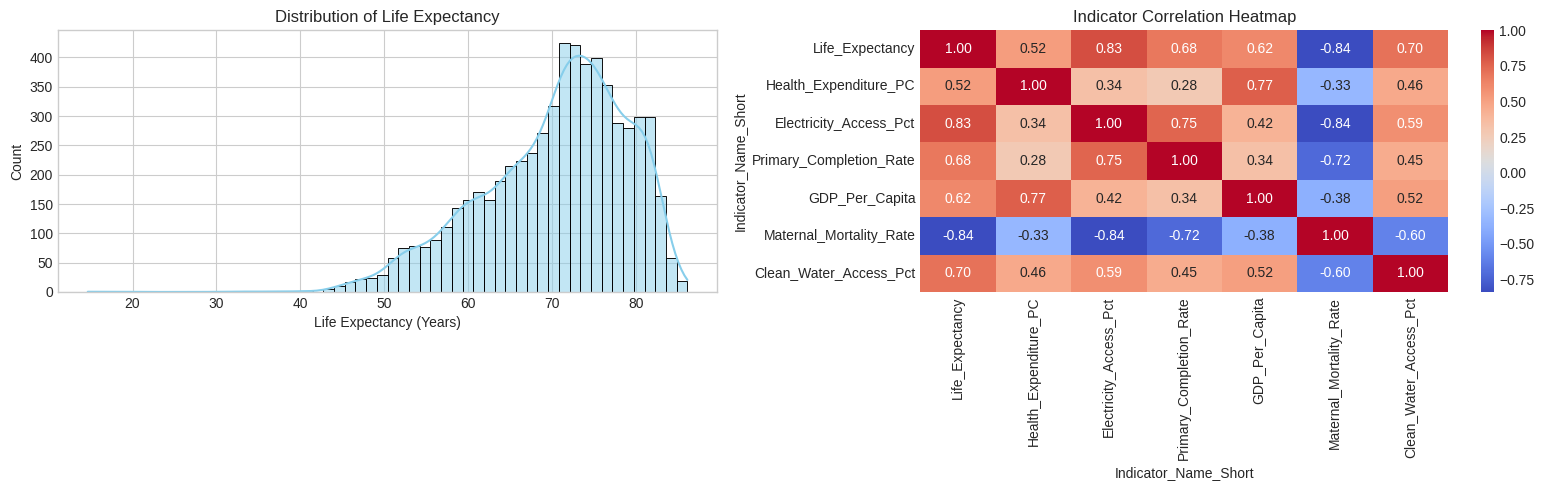

In [14]:
# Distributions and Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df_clean['Life_Expectancy'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Life Expectancy')
axes[0].set_xlabel('Life Expectancy (Years)')

sns.heatmap(df_clean[feature_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('Indicator Correlation Heatmap')
plt.tight_layout()
plt.show()

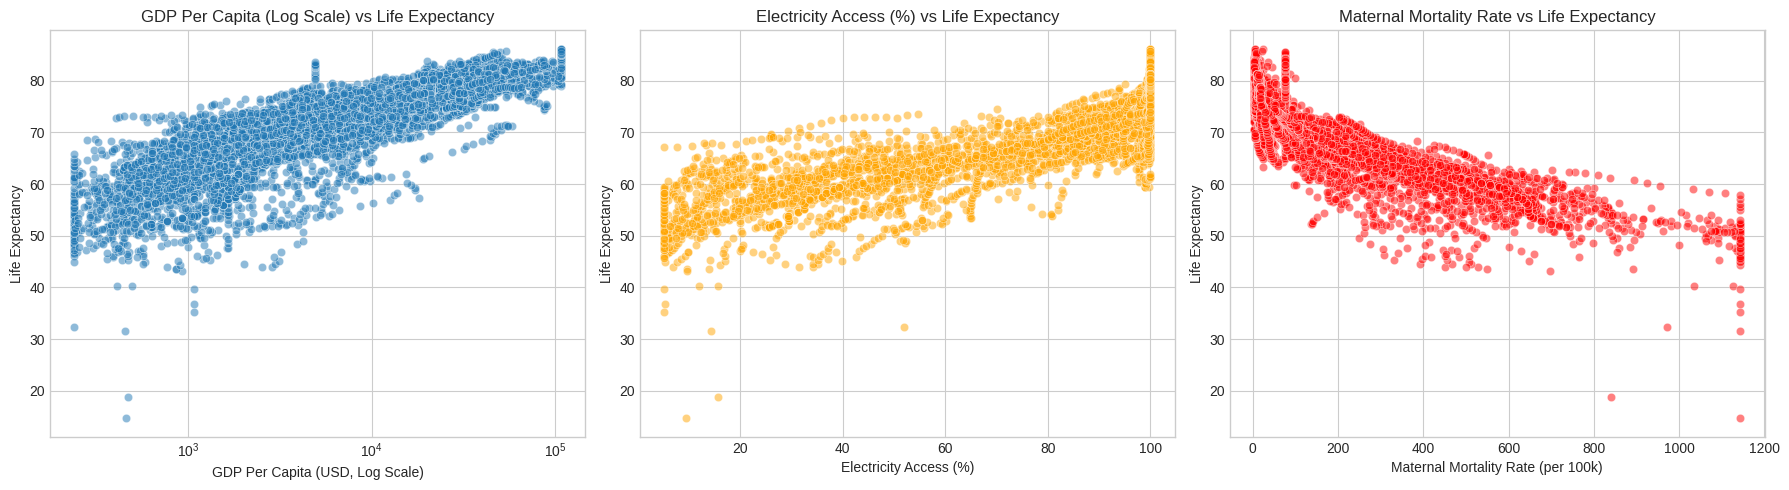

In [15]:
# Bivariate Relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df_clean, x='GDP_Per_Capita', y='Life_Expectancy', alpha=0.5, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('GDP Per Capita (Log Scale) vs Life Expectancy')
axes[0].set_xlabel('GDP Per Capita (USD, Log Scale)')
axes[0].set_ylabel('Life Expectancy')

sns.scatterplot(data=df_clean, x='Electricity_Access_Pct', y='Life_Expectancy', alpha=0.5, color='orange', ax=axes[1])
axes[1].set_title('Electricity Access (%) vs Life Expectancy')
axes[1].set_xlabel('Electricity Access (%)')
axes[1].set_ylabel('Life Expectancy')

sns.scatterplot(data=df_clean, x='Maternal_Mortality_Rate', y='Life_Expectancy', alpha=0.5, color='red', ax=axes[2])
axes[2].set_title('Maternal Mortality Rate vs Life Expectancy')
axes[2].set_xlabel('Maternal Mortality Rate (per 100k)')
axes[2].set_ylabel('Life Expectancy')

plt.tight_layout()
plt.show()

## EDA Findings

### Life Expectancy Distribution

* Life expectancy is concentrated mainly between **70 and 80 years**, with most observations around **72–75 years**.
* The lower tail indicates substantial differences in life expectancy across countries and years.

### Key Associations

| Indicator                     | Correlation with Life Expectancy | Interpretation                          |
| ----------------------------- | -------------------------------: | --------------------------------------- |
| Electricity Access            |                            +0.83 | Strong positive association             |
| Maternal Mortality Rate       |                            -0.84 | Strong negative association             |
| Clean Water Access            |                            +0.70 | Strong positive association             |
| Primary Completion Rate       |                            +0.68 | Moderate-to-strong positive association |
| GDP Per Capita                |                            +0.62 | Moderate-to-strong positive association |
| Health Expenditure Per Capita |                            +0.52 | Moderate positive association           |

### Key Insights

* Electricity access and maternal mortality show the strongest associations with life expectancy among the selected indicators.
* Clean water access and primary completion rate also show substantial positive associations.
* GDP per capita has a positive relationship with life expectancy, although the relationship appears to become less pronounced at higher income levels.
* Health expenditure per capita shows a moderate positive association with life expectancy.

### Multicollinearity Consideration

Several predictors are strongly correlated with one another, particularly electricity access, maternal mortality, and primary completion rate. This indicates potential multicollinearity and should be considered when interpreting the Linear Regression model. Tree-based models may be less sensitive to correlated predictors.


## 5. Machine Learning Modeling
In this section, we feature engineer log-transformed attributes (`GDP_Per_Capita_Log`, `Health_Exp_Log`), perform an 80/20 train-test split, and train Linear Regression, Random Forest, and XGBoost models.

In [16]:
# Feature Engineering
df_clean['GDP_Per_Capita_Log'] = np.log1p(df_clean['GDP_Per_Capita'])
df_clean['Health_Exp_Log'] = np.log1p(df_clean['Health_Expenditure_PC'])

feature_names = [
    'Health_Exp_Log',
    'Electricity_Access_Pct',
    'Primary_Completion_Rate',
    'GDP_Per_Capita_Log',
    'Maternal_Mortality_Rate',
    'Clean_Water_Access_Pct'
]

X = df_clean[feature_names]
y = df_clean['Life_Expectancy']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standard Scaling for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Models
models = {
    'Linear Regression': (LinearRegression(), X_train_scaled, X_test_scaled),
    'Random Forest': (RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test),
    'XGBoost': (xgb.XGBRegressor(n_estimators=100, random_state=42), X_train, X_test)
}

fitted_models = {}
predictions = {}

for name, (model, train_data, test_data) in models.items():
    model.fit(train_data, y_train)
    fitted_models[name] = model
    predictions[name] = model.predict(test_data)
    print(f"Trained {name} successfully.")

Trained Linear Regression successfully.
Trained Random Forest successfully.
Trained XGBoost successfully.


## 6. Model Evaluation
We evaluate model predictions using MAE, MSE, RMSE, and R² metrics, automatically identifying the top-performing model.

In [17]:
metrics = []
for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    metrics.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

eval_df = pd.DataFrame(metrics).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
display(eval_df)

best_model_name = eval_df.iloc[0]['Model']
best_model_r2 = eval_df.iloc[0]['R2 Score']
print(f"\nBest Performing Model: {best_model_name} (R2 Score: {best_model_r2:.4f})")

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest,1.138785,4.085109,2.021165,0.942212
1,XGBoost,1.242068,4.272286,2.066951,0.939564
2,Linear Regression,2.455253,11.614667,3.408030,0.835698



Best Performing Model: Random Forest (R2 Score: 0.9422)


## 7. Feature Importance / Model Interpretation
We plot Actual vs. Predicted values along with feature importance / coefficients for the best-performing model.

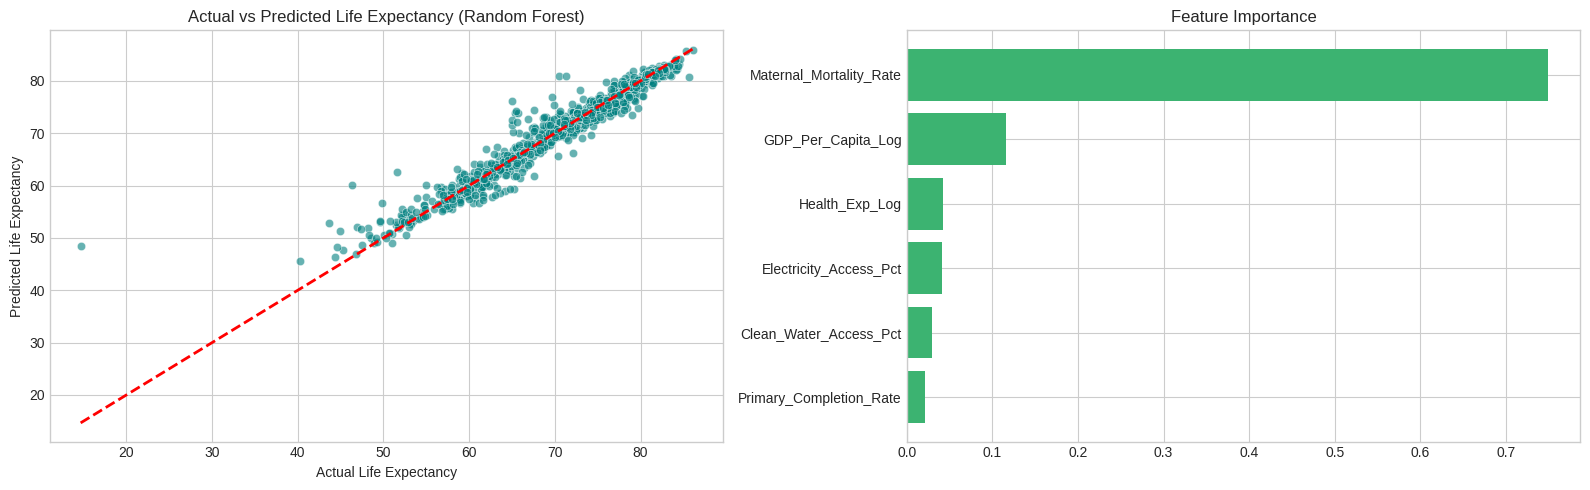

In [18]:
best_pred = predictions[best_model_name]
best_model_obj = fitted_models[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Actual vs Predicted Plot
sns.scatterplot(x=y_test, y=best_pred, alpha=0.6, ax=axes[0], color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Actual vs Predicted Life Expectancy ({best_model_name})')
axes[0].set_xlabel('Actual Life Expectancy')
axes[0].set_ylabel('Predicted Life Expectancy')

# Feature Importance / Coefficients Plot
if best_model_name == 'Linear Regression':
    importance = best_model_obj.coef_
    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance}).sort_values(by='Importance', ascending=True)
    axes[1].barh(imp_df['Feature'], imp_df['Importance'], color='mediumpurple')
    axes[1].set_title('Standardized Coefficients')
else:
    importance = best_model_obj.feature_importances_
    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance}).sort_values(by='Importance', ascending=True)
    axes[1].barh(imp_df['Feature'], imp_df['Importance'], color='mediumseagreen')
    axes[1].set_title('Feature Importance')

plt.tight_layout()
plt.show()

### Interpretation

* **Model Accuracy:** The Random Forest model achieved the best performance, with an R² score of **0.942** and an RMSE of **2.02 years**. Its predictions differ from the actual life expectancy values by approximately **1.14 years on average**, based on the MAE.

* **Key Feature Drivers:** **Maternal Mortality Rate** was the most important feature in the Random Forest model, with an approximate importance of **75%**, followed by **GDP Per Capita (Log)** at approximately **12%**. The remaining features contributed smaller proportions to the model's predictions.

## 8. Insights & Recommendations

### Key Findings

* **Health and infrastructure indicators show strong associations with life expectancy.** Electricity access and clean water access have strong positive correlations with life expectancy, while maternal mortality has a strong negative correlation.
* **Random Forest performed best among the three models**, achieving an R² of **0.942**, an RMSE of **2.02 years**, and an MAE of **1.14 years**.
* **Maternal Mortality Rate was the most important predictor** in the Random Forest model, followed by GDP Per Capita (Log), indicating that health and economic conditions provided substantial predictive information.

### Policy Recommendations

* **Healthcare Strategy:** Strengthen maternal and primary healthcare services, particularly in areas with high maternal mortality, while improving access to essential healthcare resources.
* **Infrastructure Priorities:** Continue investing in electricity and clean-water access, particularly in areas with lower service coverage, given their strong association with life expectancy.
* **Economic Development:** Support policies that improve economic conditions and access to essential services, as GDP per capita was an important predictor in the model.

- **Note on Causality:** The findings represent statistical associations and predictive relationships rather than causal effects. Policy decisions should therefore consider local socioeconomic, healthcare, and infrastructure conditions.


## 9. Model Deployment

The best-performing Random Forest model is deployed using **Gradio** to provide an interactive interface for predicting life expectancy from selected World Bank development indicators.

The interface accepts the six predictor variables used during model training and applies the same preprocessing and feature engineering steps before generating a life expectancy prediction.

In [23]:
import joblib
joblib.dump(fitted_models["Random Forest"],
            "random_forest_model.joblib")

['random_forest_model.joblib']

In [19]:
# Install Gradio
!pip install -q gradio joblib

In [25]:
import gradio as gr
import numpy as np
import pandas as pd
import joblib
import os

# ============================================================
# LOAD BEST MODEL
# ============================================================

final_model = joblib.load("random_forest_model.joblib")

MODEL_R2 = 0.9422
MODEL_RMSE = 2.02
MODEL_MAE = 1.14


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_life_expectancy(
    health_expenditure,
    electricity_access,
    primary_completion,
    gdp_per_capita,
    maternal_mortality,
    clean_water_access
):

    # Apply the same transformations used during model training
    gdp_log = np.log1p(gdp_per_capita)
    health_exp_log = np.log1p(health_expenditure)

    # Create input dataframe with exact model feature names
    input_data = pd.DataFrame([{
        "Health_Exp_Log": health_exp_log,
        "Electricity_Access_Pct": electricity_access,
        "Primary_Completion_Rate": primary_completion,
        "GDP_Per_Capita_Log": gdp_log,
        "Maternal_Mortality_Rate": maternal_mortality,
        "Clean_Water_Access_Pct": clean_water_access
    }])

    # Generate prediction
    prediction = final_model.predict(input_data)[0]
    prediction = round(float(prediction), 2)

    # Categorize prediction
    if prediction >= 75:
        category = "High Predicted Life Expectancy"
        color = "#22c55e"

    elif prediction >= 65:
        category = "Moderate Predicted Life Expectancy"
        color = "#f59e0b"

    else:
        category = "Lower Predicted Life Expectancy"
        color = "#ef4444"

    # ========================================================
    # VISIBLE RESULT CARD
    # ========================================================

    result_card = f"""
    <div style="
        width: 100%;
        box-sizing: border-box;
        background: linear-gradient(135deg, #172554 0%, #0f766e 100%);
        border: 1px solid #334155;
        border-radius: 20px;
        padding: 35px 25px;
        margin: 10px 0;
        text-align: center;
        color: white;
        box-shadow: 0 8px 25px rgba(0,0,0,0.35);
    ">

        <div style="
            font-size: 13px;
            font-weight: 700;
            letter-spacing: 1.5px;
            color: #bfdbfe;
            margin-bottom: 12px;
        ">
            ESTIMATED LIFE EXPECTANCY
        </div>

        <div style="
            font-size: 58px;
            line-height: 1;
            font-weight: 900;
            color: #ffffff;
            margin: 5px 0;
        ">
            {prediction:.2f}
        </div>

        <div style="
            font-size: 18px;
            font-weight: 500;
            color: #dbeafe;
            margin-top: 8px;
        ">
            Years
        </div>

        <div style="
            display: inline-block;
            margin-top: 18px;
            padding: 9px 18px;
            border-radius: 30px;
            background: rgba(15,23,42,0.65);
            border: 1px solid {color};
            color: {color};
            font-size: 15px;
            font-weight: 700;
        ">
            {category}
        </div>

    </div>
    """

    # ========================================================
    # INTERPRETATION
    # ========================================================

    interpretation = f"""
### Prediction Summary

**Estimated Life Expectancy:** {prediction:.2f} years

**Prediction Category:** {category}

The estimate is generated using six development indicators from the
World Bank World Development Indicators dataset.

**Model:** Random Forest Regressor
**R²:** 0.942
**Mean Absolute Error:** 1.14 years
"""

    return result_card, interpretation


# ============================================================
# CUSTOM CSS
# ============================================================

custom_css = """

/* ==========================================================
   GLOBAL
   ========================================================== */

.gradio-container {
    background: #eaf0f6 !important;
    color: #172033 !important;
    font-family: Inter, Arial, sans-serif !important;
}

body {
    background: #eaf0f6 !important;
}


/* ==========================================================
   HERO
   ========================================================== */

.hero {
    background:
        linear-gradient(
            135deg,
            #172554 0%,
            #1e3a8a 45%,
            #0f766e 100%
        );

    padding: 38px;
    border-radius: 22px;
    margin-bottom: 24px;

    border: 1px solid #334155;

    box-shadow:
        0 10px 30px rgba(0,0,0,0.30);
}

.hero-title {
    font-size: 40px;
    font-weight: 800;
    color: #ffffff;
    line-height: 1.15;
}

.hero-subtitle {
    color: #bfdbfe;
    font-size: 18px;
    margin-top: 10px;
}

.hero-text {
    color: #dbeafe;
    margin-top: 15px;
    font-size: 15px;
    line-height: 1.6;
}


/* ==========================================================
   CARDS
   ========================================================== */

.card {
    background: #ffffff !important;
    border: 1px solid #d6dee8 !important;
    border-radius: 20px !important;
    padding: 22px !important;
    box-shadow: 0 8px 24px rgba(15, 23, 42, 0.08) !important;
}


/* ==========================================================
   CARD HEADINGS
   ========================================================== */

.card h2,
.card h3,
.card h4,
.gradio-container h2,
.gradio-container h3 {
    color: #172033 !important;
    font-weight: 800 !important;
}


/* ==========================================================
   CARD TEXT
   ========================================================== */

.card p,
.card li,
.card label {
    color: #334155 !important;
}


/* ==========================================================
   MODEL METRICS
   ========================================================== */

.metric-card {
    background: #111827;

    border: 1px solid #334155;

    border-radius: 16px;

    text-align: center;

    padding: 17px;

    min-height: 75px;
}

.metric-title {
    color: #60a5fa;
    font-size: 13px;
    font-weight: 600;
    margin-bottom: 5px;
}

.metric-value {
    color: #f8fafc;
    font-size: 23px;
    font-weight: 800;
}


/* ==========================================================
   BUTTON
   ========================================================== */

#predict-button {
    background:
        linear-gradient(
            135deg,
            #2563eb,
            #06b6d4
        ) !important;

    color: #ffffff !important;

    border: none !important;

    border-radius: 12px !important;

    font-weight: 700 !important;

    height: 52px;

    margin-top: 10px;

    box-shadow:
        0 5px 18px rgba(37,99,235,0.25);
}

#predict-button:hover {
    filter: brightness(1.08);
}


/* ==========================================================
   INPUT LABELS
   ========================================================== */

label {
    color: #334155 !important;
}


/* ==========================================================
   SLIDERS
   ========================================================== */

input[type="range"] {
    accent-color: #38bdf8;
}


/* ==========================================================
   FOOTER
   ========================================================== */

.footer {
    text-align: center;
    color: #64748b;
    margin-top: 25px;
    padding: 15px;
    font-size: 12px;
}

"""


# ============================================================
# APP
# ============================================================

with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="blue",
        neutral_hue="slate"
    ),
    css=custom_css,
    title="Life Expectancy Prediction Dashboard"
) as demo:

    # ========================================================
    # HERO
    # ========================================================

    gr.HTML(
        """
        <div class="hero">

            <div class="hero-title">
                🌍 Life Expectancy Prediction Dashboard
            </div>

            <div class="hero-subtitle">
                World Bank World Development Indicators
            </div>

            <div class="hero-text">
                Explore how health, economic, education, and
                infrastructure indicators relate to predicted
                life expectancy.
            </div>

        </div>
        """
    )


    # ========================================================
    # MODEL PERFORMANCE
    # ========================================================

    with gr.Row():

        gr.HTML(
            """
            <div class="metric-card">
                <div class="metric-title">MODEL</div>
                <div class="metric-value">Random Forest</div>
            </div>
            """
        )

        gr.HTML(
            f"""
            <div class="metric-card">
                <div class="metric-title">R² SCORE</div>
                <div class="metric-value">{MODEL_R2:.3f}</div>
            </div>
            """
        )

        gr.HTML(
            f"""
            <div class="metric-card">
                <div class="metric-title">RMSE</div>
                <div class="metric-value">{MODEL_RMSE:.2f}</div>
            </div>
            """
        )

        gr.HTML(
            f"""
            <div class="metric-card">
                <div class="metric-title">MAE</div>
                <div class="metric-value">{MODEL_MAE:.2f} yrs</div>
            </div>
            """
        )


    # ========================================================
    # MAIN CONTENT
    # ========================================================

    with gr.Row():

        # ----------------------------------------------------
        # INPUT SECTION
        # ----------------------------------------------------

        with gr.Column(
            scale=1,
            elem_classes="card"
        ):

            gr.Markdown("## Development Indicators")

            health_expenditure = gr.Number(
                label="🏥 Health Expenditure per Capita (USD)",
                value=350,
                minimum=0
            )

            electricity_access = gr.Slider(
                minimum=0,
                maximum=100,
                value=75,
                step=1,
                label="⚡ Electricity Access (%)"
            )

            primary_completion = gr.Slider(
                minimum=0,
                maximum=100,
                value=85,
                step=1,
                label="🎓 Primary Completion Rate (%)"
            )

            gdp_per_capita = gr.Number(
                label="💰 GDP per Capita (USD)",
                value=5000,
                minimum=0
            )

            maternal_mortality = gr.Number(
                label="👩 Maternal Mortality Rate (per 100k)",
                value=150,
                minimum=0
            )

            clean_water_access = gr.Slider(
                minimum=0,
                maximum=100,
                value=80,
                step=1,
                label="💧 Clean Water Access (%)"
            )

            predict_button = gr.Button(
                "Predict Life Expectancy",
                variant="primary",
                size="lg",
                elem_id="predict-button"
            )


        # ----------------------------------------------------
        # RESULT SECTION
        # ----------------------------------------------------

        with gr.Column(
            scale=1,
            elem_classes="card"
        ):

            gr.Markdown("## Prediction Result")

            prediction_card = gr.HTML(
                value="""
                <div style="
                    background:#ffffff;
                    border:1px solid #334155;
                    border-radius:20px;
                    padding:45px 20px;
                    text-align:center;
                    color:#94a3b8;
                ">

                    <div style="
                        font-size:13px;
                        letter-spacing:1px;
                        font-weight:700;
                        margin-bottom:12px;
                    ">
                        PREDICTION RESULT
                    </div>

                    <div style="
                        font-size:16px;
                        line-height:1.5;
                    ">
                        Enter the development indicators
                        and click <b>Predict Life Expectancy</b>.
                    </div>

                </div>
                """
            )

            interpretation = gr.Markdown(
                """
### Prediction Summary

Your prediction will appear here after running the model.
"""
            )


    # ========================================================
    # EXAMPLE SCENARIOS
    # ========================================================

    gr.Markdown("## Example Development Profiles")

    gr.Examples(
        examples=[
            [100, 30, 60, 1200, 550, 45],
            [450, 85, 88, 6500, 180, 82],
            [4500, 99, 98, 45000, 12, 99]
        ],

        inputs=[
            health_expenditure,
            electricity_access,
            primary_completion,
            gdp_per_capita,
            maternal_mortality,
            clean_water_access
        ]
    )


    # ========================================================
    # ABOUT THE MODEL
    # ========================================================

    with gr.Accordion(
        "About This Model",
        open=False
    ):

        gr.Markdown(
            """
### Model Inputs

- Health Expenditure Per Capita
- Electricity Access
- Primary Completion Rate
- GDP Per Capita
- Maternal Mortality Rate
- Clean Water Access

### Target

**Life Expectancy at Birth (Years)**

### Dataset

**World Bank World Development Indicators (WDI)**

### Model

**Random Forest Regressor**

The model was trained using development indicators from
2000–2022. GDP per capita and health expenditure were
log-transformed before modeling.
"""
        )


    # ========================================================
    # FOOTER
    # ========================================================

    gr.HTML(
        """
        <div class="footer">
            Life Expectancy Prediction Model • World Bank WDI
        </div>
        """
    )


    # ========================================================
    # EVENT
    # ========================================================

    predict_button.click(
        fn=predict_life_expectancy,

        inputs=[
            health_expenditure,
            electricity_access,
            primary_completion,
            gdp_per_capita,
            maternal_mortality,
            clean_water_access
        ],

        outputs=[
            prediction_card,
            interpretation
        ]
    )


# ============================================================
# LAUNCH
# ============================================================

demo.launch(share=True)

/tmp/ipykernel_631/358710961.py:353: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://de45176b0b7331e77a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 10. Conclusion
This project completed an end-to-end data science workflow using the World Bank WDI dataset to model life expectancy across countries.

The project analyzed factors influencing life expectancy using selected indicators from the dataset. Exploratory analysis showed strong relationships between life expectancy and indicators such as electricity access, maternal mortality, clean water access, education, GDP per capita, and health expenditure.

Three regression models were developed and evaluated. The **Random Forest Regressor** achieved the best performance, with an **R² score of 0.9422, RMSE of 2.02 years, and MAE of 1.14 years**. This indicates that the model provides strong predictive performance on the test data.

Overall, the findings demonstrate that economic, health, education, and infrastructure indicators can provide useful signals for predicting life expectancy. The results can support evidence-based analysis of development priorities, while recognizing that the observed relationships are associative and do not establish causation.


## 11. Limitations & Future Work

### Limitations

* **Data Availability:** Some indicators contain missing values, requiring imputation during preprocessing.
* **Indicator Selection:** The analysis uses a limited number of WDI indicators and may not capture all factors influencing life expectancy.
* **Non-Causal Relationships:** The results identify statistical relationships and predictive patterns but do not establish that one indicator directly causes changes in life expectancy.
* **Validation Approach:** The model uses a random train-test split, which may not fully account for the time-series nature of the data.

### Future Work

* Include additional World Bank indicators related to nutrition, healthcare access, poverty, and environmental conditions.
* Apply time-based validation to better evaluate predictions across different years.
* Perform hyperparameter tuning to further improve model performance.
* Use explainability techniques such as SHAP to provide deeper insight into individual predictions and feature contributions.
* Expand the deployment interface to support country-level comparisons and scenario analysis.